# Comparison between installed capacities in Denmark 2025
This notebook aims to compare the installed electricities in Denmark 2025, using the powerplantmatching dataset, data from Energistyrelsen and the output of the network model generated from PyPSA-eur.

## Load data and networks
First load the data from the csv files and network file

In [143]:
import pandas as pd
import numpy as np
import pypsa
from pathlib import Path
import matplotlib.pyplot as plt

# The notebook is located in the "notebooks" directory
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT_DIR / "data"
NET_DIR = DATA_DIR / "networks"

# Load powerplant data
df_ens = pd.read_csv(DATA_DIR / "powerplants.csv")
df_ppm = pd.read_csv(DATA_DIR / "powerplants_PPM.csv")

# Raw Energistyrelsen data
df_ens_pp = pd.read_csv(
        DATA_DIR / "ENS_power_plant_register.csv",
        sep=";",
        decimal=",",
    )

# Load network
# OG_network = pypsa.Network(NET_DIR / "base_s_3_OG.nc") # Original from powerplantmatching
# OGI_network = pypsa.Network(NET_DIR / "base_s_3_OG_Irena.nc") # Original from powerplantmatching + IRENA
# ENS_network = pypsa.Network(NET_DIR / "base_s_3_updated_PPM.nc") # Data from Energistyrelsen
# OLD_network = pypsa.Network(NET_DIR / "no_OCGT.nc") # Old network for comparison


TEST_network = pypsa.Network(NET_DIR / "ny_ppm.nc") # TEST networks to compare with ENS
ELEC_network = pypsa.Network(NET_DIR / "base_s_3_elec_.nc") # Electrical only network
FIX_network = pypsa.Network(NET_DIR / "base_wte_true.nc") # Fixed capacity network to compare with ENS




INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


---

## Compare powerplantmatching original powerplants.csv and the modified powerplants.csv using Energistyrelsens data

Here we only compare the power capacitites

Installed capacities per fueltype in Denmark active in 2025 [MW]:
                      ENS     PPM
Fueltype                         
Biogas            0.74000     0.0
Hydro             6.93900     0.0
Natural Gas       0.64000  1461.2
Oil             642.08800   126.0
Solar          5068.32368  3364.9
Wind           7499.92134  4609.4
Hard Coal         0.00000   716.0
Solid Biomass     0.00000  1781.0
Waste             0.00000   153.0


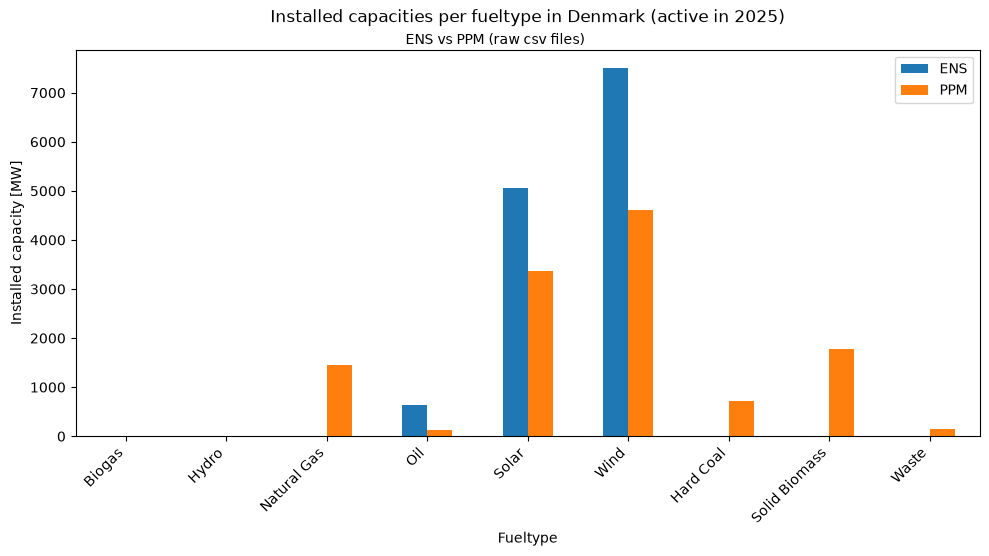

In [144]:

def active_in_year(df, year):
    is_dk = df["Country"] == "Denmark"
    is_in = df["DateIn"] <= year
    is_not_out = df["DateOut"].isna() | (df["DateOut"] >= year)
    return df.loc[is_dk & is_in & is_not_out]

YEAR = 2025

# lets look at the installed capacities per fueltype in Denmark active in the given year

df_ens_dk = active_in_year(df_ens, YEAR)
df_ppm_dk = active_in_year(df_ppm, YEAR)

cap_ens = df_ens_dk.groupby("Fueltype")["Capacity"].sum() # MW
cap_ppm = df_ppm_dk.groupby("Fueltype")["Capacity"].sum() # MW

comparison = pd.concat([cap_ens, cap_ppm], axis=1, keys=["ENS", "PPM"]).fillna(0)
print(f"Installed capacities per fueltype in Denmark active in {YEAR} [MW]:")
print(comparison)

comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title(f"Installed capacities per fueltype in Denmark (active in {YEAR})", y = 1.05)
plt.suptitle("ENS vs PPM (raw csv files)", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [145]:
df = df_ens_dk.copy()


def pypsa_carrier(row):
    fuel = row["Fueltype"]
    tech = row["Technology"]

    # -------------------------------------------------
    # Natural gas
    # build_powerplants.py:
    # Steam Turbine      -> CCGT
    # Combustion Engine  -> OCGT
    # Not Found / NaN    -> CCGT
    #
    # add_electricity.py:
    # Natural Gas carrier is then replaced by Technology
    # -------------------------------------------------
    if fuel == "Natural Gas":

        if tech == "OCGT":
            return "OCGT"

        elif tech == "CCGT":
            return "CCGT"

        elif tech == "Combustion Engine":
            return "OCGT"

        elif tech == "Steam Turbine":
            return "CCGT"

        elif pd.isna(tech) or tech == "Not Found":
            return "CCGT"

        else:
            # Be careful here:
            # PyPSA-Eur does NOT blindly make every unknown gas technology CCGT.
            return pd.NA


    # -------------------------------------------------
    # Biomass / biogas
    # Solid Biomass -> Bioenergy -> biomass
    # Biogas        -> Bioenergy -> biomass
    # -------------------------------------------------
    elif fuel in ["Solid Biomass", "Biogas", "Bioenergy"]:
        return "biomass"


    # -------------------------------------------------
    # Coal
    # Hard Coal -> coal
    # -------------------------------------------------
    elif fuel == "Hard Coal":
        return "coal"


    # -------------------------------------------------
    # Oil
    # Remains oil
    # -------------------------------------------------
    elif fuel == "Oil":
        return "oil"


    # -------------------------------------------------
    # Waste
    # Remains waste
    # -------------------------------------------------
    elif fuel == "Waste":
        return "waste"


    # -------------------------------------------------
    # Nuclear
    # Remains nuclear
    # -------------------------------------------------
    elif fuel == "Nuclear":
        return "nuclear"


    # -------------------------------------------------
    # Hydro
    # add_electricity.py maps Hydro carrier according to Technology
    # -------------------------------------------------
    elif fuel == "Hydro":

        if tech == "Run-Of-River":
            return "ror"

        elif tech == "Reservoir":
            return "hydro"

        elif tech == "Pumped Storage":
            return "PHS"

        else:
            return pd.NA


    # -------------------------------------------------
    # Wind and solar
    #
    # IMPORTANT:
    # These should normally NOT be mapped from powerplants.csv.
    # PyPSA-Eur adds wind/solar separately using renewable profiles.
    # Keep these only if you are creating a comparison category
    # for your ENS dataset.
    # -------------------------------------------------
    elif fuel == "Solar":
        return "solar"

    elif fuel == "Wind":

        if tech == "Onshore":
            return "onwind"

        elif tech == "Offshore":
            # ENS does not tell you whether PyPSA represents it as
            # offwind-ac, offwind-dc, or offwind-float.
            return "offwind-ac"

        else:
            return pd.NA


    return pd.NA


df["PyPSA_carrier"] = df.apply(pypsa_carrier, axis=1)

                      ENS        ELEC
OCGT              0.64000  1049.60200
biomass           0.74000  1445.15000
offwind-ac     2598.50004  2574.90004
oil             642.08800   450.68800
onwind         4879.76300  4529.40800
ror               6.93900     6.63400
solar          5068.32368  4987.61719
CCGT              0.00000  1629.83000
coal              0.00000   385.00000
offwind-dc        0.00000     0.00000
offwind-float     0.00000     0.00000
solar-hsat        0.00000     0.00000
waste             0.00000   293.20000


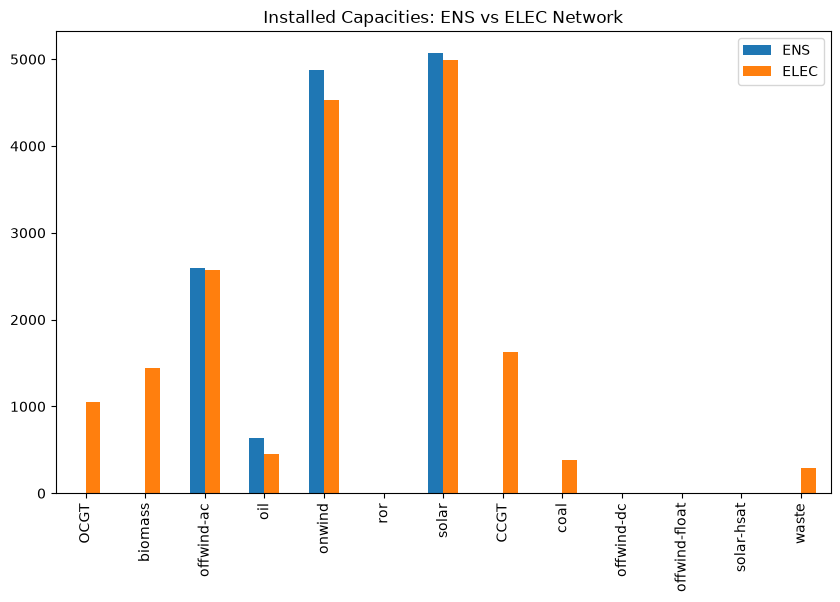

In [146]:
# compare elec network installed capacities with ENS data in Denmark

dk_buses = ELEC_network.buses.index[
    ELEC_network.buses["country"].eq("DK")
]

cap_elec = (
    ELEC_network.generators.loc[
        ELEC_network.generators["bus"].isin(dk_buses)
    ]
    .groupby("carrier")["p_nom_opt"]
    .sum()
)

cap_ens = df.groupby("PyPSA_carrier")["Capacity"].sum()  # MW

comparison = pd.concat([cap_ens, cap_elec], axis=1, keys=["ENS", "ELEC"]).fillna(0)

# print the comparison of installed capacities between ELEC network and ENS data
print(comparison)

# plot the comparison
comparison.plot(kind="bar", figsize=(10, 6), title="Installed Capacities: ENS vs ELEC Network")
plt.show()


In [147]:
# Select Danish buses from the network
dk_buses = ELEC_network.buses.index[
    ELEC_network.buses["country"].eq("DK")
]

# Select generators connected to Danish buses
elec_dk_generators = ELEC_network.generators.loc[
    ELEC_network.generators["bus"].isin(dk_buses)
]

# Total installed capacities
cap_elec_total = elec_dk_generators["p_nom_opt"].sum()
cap_ens_total = df["Capacity"].sum()

print("Total installed capacity in ELEC network [MW]:")
print(cap_elec_total)

print("\nTotal installed capacity in ENS data [MW]:")
print(cap_ens_total)

Total installed capacity in ELEC network [MW]:
17352.02923

Total installed capacity in ENS data [MW]:
13218.65202


            Energistyrelsen  FIX Network  TEST Network
OCGT                0.64000    698.50200       0.64000
biomass             0.74000   1994.15000       0.74000
offwind-ac       2598.50004   2574.90004    2574.90004
oil               642.08800    711.68800     621.68800
onwind           4879.76300   4529.40800    4529.40800
ror                 6.93900      0.00000       0.00000
solar            5068.32368   4987.61719    4987.61719
CCGT                0.00000   1076.04000       0.00000
coal                0.00000    385.00000       0.00000


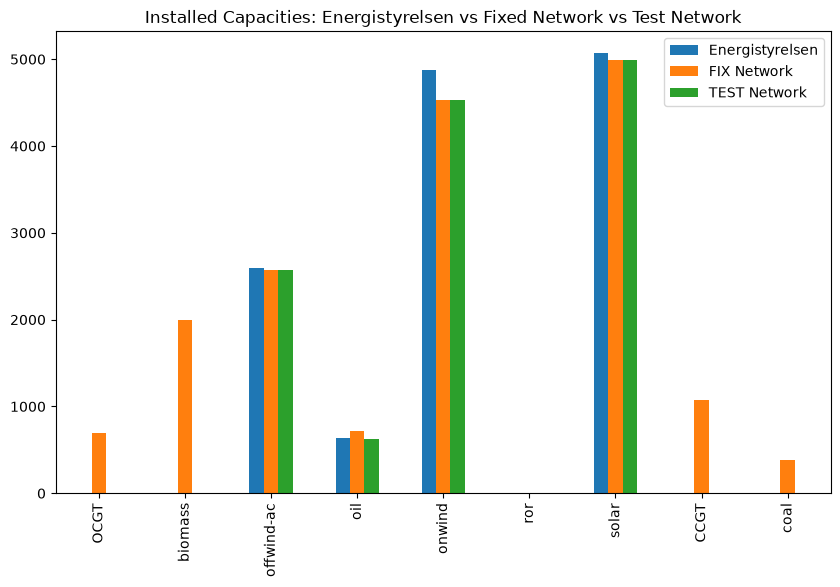

In [148]:
# Select Danish AC and DC buses
dk_ac_dc_buses = FIX_network.buses.index[
    FIX_network.buses["carrier"].isin(["AC"])
    & (FIX_network.buses["country"] == "DK")
]

# Keep only links whose output bus (bus1) is a Danish AC or DC bus and generators connected to these buses
df_fix_dk = FIX_network.links.loc[
    FIX_network.links["bus1"].isin(dk_ac_dc_buses)
]
df_fix_dk_gen = FIX_network.generators.loc[
    FIX_network.generators["bus"].isin(dk_ac_dc_buses)
]

# Add the capacitiies of the links and generator in the OLD_network
dk_ac_dc_buses_test = TEST_network.buses.index[
    TEST_network.buses["carrier"].isin(["AC"])
    & (TEST_network.buses["country"] == "DK")
]

df_test_dk = TEST_network.links.loc[
    TEST_network.links["bus1"].isin(dk_ac_dc_buses_test)
]
df_test_dk_gen = TEST_network.generators.loc[
    TEST_network.generators["bus"].isin(dk_ac_dc_buses_test)
]


cap_elec_test = pd.concat([
    df_test_dk.groupby("carrier")["p_nom_min"].sum(),
    df_test_dk_gen.groupby("carrier")["p_nom_min"].sum()
], axis=0).groupby(level=0).sum()

cap_elec = pd.concat([
    df_fix_dk.groupby("carrier")["p_nom_min"].sum(),
    df_fix_dk_gen.groupby("carrier")["p_nom_min"].sum()
], axis=0).groupby(level=0).sum()

# compare the installed capacities per technology with energistyrelsen data
cap_ens = df.groupby("PyPSA_carrier")["Capacity"].sum() # MW

# print the comparison of installed capacities between FIX, OLD, and ENS data
comparison = pd.concat([cap_ens, cap_elec, cap_elec_test], axis=1, keys=["Energistyrelsen", "FIX Network", "TEST Network"]).fillna(0)
# if both ENS and fix is zero, remove row
comparison = comparison.loc[~((comparison["Energistyrelsen"] == 0) & (comparison["FIX Network"] == 0) & (comparison["TEST Network"] == 0))]
print(comparison)

# plot the comparison
comparison.plot(kind="bar", figsize=(10, 6), title="Installed Capacities: Energistyrelsen vs Fixed Network vs Test Network")
plt.show()

In [149]:
# from ENS dataset sum the el_kapacitet for solid biomass as fuel type and divide with the sum of varmekapacitet for solid biomass
solid_biomass_el_capacity = df_ens_pp.loc[
    df_ens_pp["Hovedbrændselsgruppe"] == "fast biomasse",
    "elkapacitet_MW"
].sum()

solid_biomass_heat_capacity = df_ens_pp.loc[
    df_ens_pp["Hovedbrændselsgruppe"] == "fast biomasse",
    "varmekapacitet_MW"
].sum()

solid_biomass_ratio = solid_biomass_el_capacity / solid_biomass_heat_capacity if solid_biomass_heat_capacity > 0 else None
print(f"Solid biomass ratio (el/heat): {solid_biomass_ratio}")
print(solid_biomass_heat_capacity)

Solid biomass ratio (el/heat): 0.3388718519981736
5558.526


                               Energistyrelsen  FIX Network  TEST Network
OCGT                                   0.64000          0.0      0.000000
biomass                                0.74000          0.0      0.000000
offwind-ac                          2598.50004          0.0   2574.900040
oil                                  642.08800          0.0      0.000000
onwind                              4879.76300          0.0   4529.408000
ror                                    6.93900          0.0      6.634000
solar                               5068.32368          0.0   4987.617190
DC                                     0.00000          0.0   1880.000000
H2 Electrolysis                        0.00000          0.0     26.174562
electricity distribution grid          0.00000          0.0   5026.237427


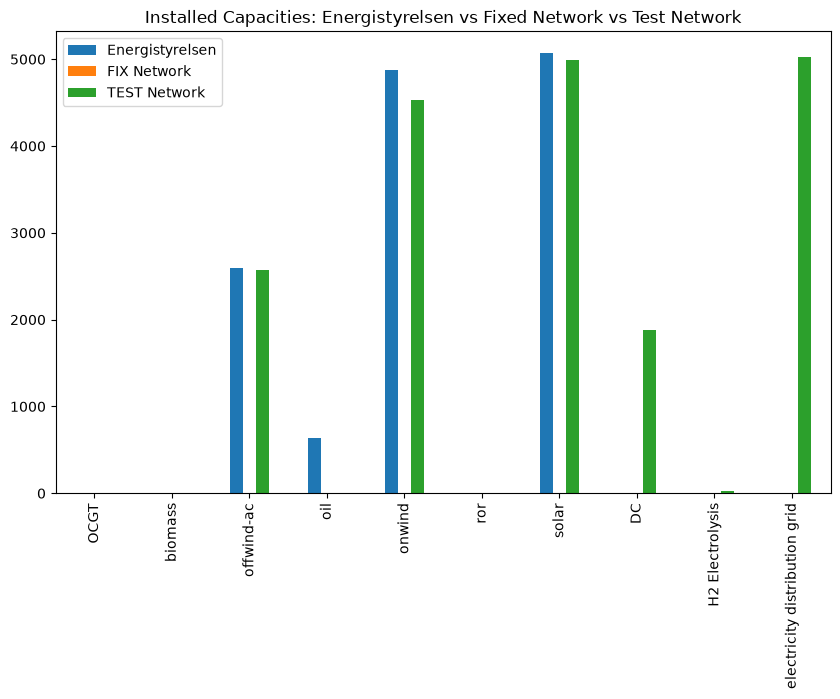

In [151]:
# Select Danish AC and DC buses
dk_ac_dc_buses = FIX_network.buses.index[
    FIX_network.buses["carrier"].isin(FIX_network.buses["country"] == "DK")
]

# Keep only links whose output bus (bus1) is a Danish AC or DC bus and generators connected to these buses
df_fix_dk = FIX_network.links.loc[
    FIX_network.links["bus0"].isin(dk_ac_dc_buses)
]
df_fix_dk_gen = FIX_network.generators.loc[
    FIX_network.generators["bus"].isin(dk_ac_dc_buses)
]

# Add the capacitiies of the links and generator in the OLD_network
dk_ac_dc_buses_test = TEST_network.buses.index[
    TEST_network.buses["carrier"].isin(["AC"])
    & (TEST_network.buses["country"] == "DK")
]

df_test_dk = TEST_network.links.loc[
    TEST_network.links["bus0"].isin(dk_ac_dc_buses_test)
]
df_test_dk_gen = TEST_network.generators.loc[
    TEST_network.generators["bus"].isin(dk_ac_dc_buses_test)
]


cap_elec_test = pd.concat([
    df_test_dk.groupby("carrier")["p_nom_opt"].sum(),
    df_test_dk_gen.groupby("carrier")["p_nom_opt"].sum()
], axis=0).groupby(level=0).sum()

cap_elec = pd.concat([
    df_fix_dk.groupby("carrier")["p_nom_opt"].sum(),
    df_fix_dk_gen.groupby("carrier")["p_nom_opt"].sum()
], axis=0).groupby(level=0).sum()

# compare the installed capacities per technology with energistyrelsen data
cap_ens = df.groupby("PyPSA_carrier")["Capacity"].sum() # MW

# print the comparison of installed capacities between FIX, OLD, and ENS data
comparison = pd.concat([cap_ens, cap_elec, cap_elec_test], axis=1, keys=["Energistyrelsen", "FIX Network", "TEST Network"]).fillna(0)
# if both ENS and fix is zero, remove row
comparison = comparison.loc[~((comparison["Energistyrelsen"] == 0) & (comparison["FIX Network"] == 0) & (comparison["TEST Network"] == 0))]
print(comparison)

# plot the comparison
comparison.plot(kind="bar", figsize=(10, 6), title="Installed Capacities: Energistyrelsen vs Fixed Network vs Test Network")
plt.show()

---

In [152]:
# check energistyrelsen capacities for power if set == CHP
df_chp_ens = df.loc[df["Set"] == "CHP"]
cap_chp_ens = df_chp_ens.groupby("PyPSA_carrier")["Capacity"].sum() # MW
print(cap_chp_ens)

Series([], Name: Capacity, dtype: float64)


## Investigating the heat capacitites from Energistyrelsens data


In [153]:
# Filter Energistyrelsen installations active at the end of 2025
END_2025 = pd.Timestamp(f"{YEAR}-12-31")

df_ens_pp["idriftdato"] = pd.to_datetime(
    df_ens_pp["idriftdato"], errors="coerce"
)
df_ens_pp["skrotdato"] = pd.to_datetime(
    df_ens_pp["skrotdato"], errors="coerce"
)

active_mask = (
    (df_ens_pp["idriftdato"].isna() | (df_ens_pp["idriftdato"] <= END_2025))
    & (df_ens_pp["skrotdato"].isna() | (df_ens_pp["skrotdato"] > END_2025))
    & (df_ens_pp["Hovedbrændselsgruppe"] != "Ej i drift i 2025")
)

df_ens_pp_active = df_ens_pp.loc[active_mask].copy()


In [154]:
# Only keep plants explicitly connected to district heating
df_ens_pp_active["supplies_to_district_heating"] = (
    df_ens_pp_active["fv_net"].notna()
    & df_ens_pp_active["fv_net"].astype(str).str.strip().ne("")
)

# sum the 'varmekapacitet_MW' for installations that supply to district heating
total_dh_MW = df_ens_pp_active.loc[
    df_ens_pp_active["supplies_to_district_heating"], "varmekapacitet_MW"
].sum()

print(f"Total district heating capacity: {total_dh_MW} MW (source: Energistyrelsen 2025)")

Total district heating capacity: 22567.126000000004 MW (source: Energistyrelsen 2025)


In [157]:
# print only where elkapacitet_MW == 0 (heat only plants) and sum for each pair of 'Hovedbrændselsgruppe' and 'anlaegstype_navn'
total_dh_heat_only_by_type_and_group = df_ens_pp_active.loc[
    (df_ens_pp_active['supplies_to_district_heating']) &
    (df_ens_pp_active['elkapacitet_MW'] == 0)
].groupby(['Hovedbrændselsgruppe', 'anlaegstype_navn'])['varmekapacitet_MW'].sum()

print("Total district heating capacity by main fuel group and type for heat only plants:")
print(total_dh_heat_only_by_type_and_group)

Total district heating capacity by main fuel group and type for heat only plants:
Hovedbrændselsgruppe  anlaegstype_navn         
affald                Kedel                          92.000
bio-olie              Kedel                         395.460
biogas                Kedel                          39.070
braendselsfrit        Anden                          10.500
                      Geotermi                        8.300
                      Overskudsvarme                335.805
                      Varmepumpe Overskudsvarme     109.705
elektricitet          Elpatron                     2042.095
                      Varmepumpe Anden                5.700
                      Varmepumpe Overskudsvarme       1.200
                      Varmepumpe røggas              31.620
fast biomasse         Bioforgasn. m. KE               5.500
                      Dampkedel                      19.000
                      Kedel                        1983.486
naturgas              Dampkede

In [156]:
# sum for each pair of 'Hovedbrændselsgruppe' and 'anlaegstype_navn' that supplies to district heating, this is installed capacity before efficiency losses
total_dh_by_type_and_group = df_ens_pp_active.loc[
    df_ens_pp_active['supplies_to_district_heating']
].groupby(['Hovedbrændselsgruppe', 'anlaegstype_navn'])['varmekapacitet_MW'].sum()


print("Total district heating capacity by main fuel group and type:")
print(total_dh_by_type_and_group)

Total district heating capacity by main fuel group and type:
Hovedbrændselsgruppe  anlaegstype_navn         
affald                Dampturbine                  1006.670
                      Kedel                          92.000
                      Kombianlæg                    170.800
bio-olie              Kedel                         395.460
biogas                Forbrændingsmotor             115.473
                      Kedel                          39.070
braendselsfrit        Anden                          10.500
                      Geotermi                        8.300
                      Overskudsvarme                335.805
                      Varmepumpe Overskudsvarme     109.705
elektricitet          Elpatron                     2042.095
                      Varmepumpe Anden                5.700
                      Varmepumpe Overskudsvarme       1.200
                      Varmepumpe røggas              31.620
fast biomasse         Bioforgasn. m. FM            

In [ ]:
def map_ens_to_pypsa_central_heat(row):
    """
    Map Energistyrelsen district-heating plants to PyPSA-Eur
    urban central heating technologies.

    Expected columns:
        Hovedbrændselsgruppe
        anlaegstype_navn
        elkapacitet_MW
        varmekapacitet_MW
    """

    fuel = str(row["Hovedbrændselsgruppe"]).strip().lower()
    tech = str(row["anlaegstype_navn"]).strip().lower()

    el_cap = pd.to_numeric(row.get("elkapacitet_MW", np.nan), errors="coerce")
    heat_cap = pd.to_numeric(row.get("varmekapacitet_MW", np.nan), errors="coerce")

    has_electricity = pd.notna(el_cap) and el_cap > 0
    has_heat = pd.notna(heat_cap) and heat_cap > 0

    # ---------------------------------------------------------
    # ELECTRIC HEATING
    # ---------------------------------------------------------
    if fuel == "elektricitet":

        if tech == "elpatron":
            return "urban central resistive heater"

        if "varmepumpe" in tech:
            # Waste/flue-gas HPs do not have a perfect native
            # PyPSA-Eur equivalent.
            if "overskudsvarme" in tech:
                return "urban central excess heat heat pump"

            if "røggas" in tech:
                return "urban central excess heat heat pump"

            return "urban central air heat pump"

    # ---------------------------------------------------------
    # AMBIENT HEAT / HEAT PUMPS
    # ---------------------------------------------------------
    if fuel == "omgivelsesvarme":

        if tech == "varmepumpe luft":
            return "urban central air heat pump"

        if tech == "varmepumpe havvand":
            return "urban central sea_water heat pump"

        if tech == "varmepumpe grundvand":
            # Approximation: PyPSA-Eur does not have a separate
            # groundwater central HP category.
            return "urban central geothermal heat pump"

        if tech == "varmepumpe spildevand":
            return "urban central excess heat heat pump"

        if tech in [
            "varmepumpe",
            "varmepumpe anden",
            "varmepumpe kombi",
        ]:
            return "urban central air heat pump"

    # ---------------------------------------------------------
    # SOLAR THERMAL
    # ---------------------------------------------------------
    if fuel == "solenergi":

        if tech == "solvarme":
            return "urban central solar thermal"

        if "varmepumpe" in tech:
            return "urban central solar heat pump"

    # ---------------------------------------------------------
    # FUEL-FREE / DIRECT HEAT
    # ---------------------------------------------------------
    if fuel in ["braendselsfrit", "brændselsfrit"]:

        if tech == "geotermi":
            return "urban central geothermal heat direct utilisation"

        if tech == "overskudsvarme":
            return "urban central excess heat"

        if "varmepumpe" in tech and "overskudsvarme" in tech:
            return "urban central excess heat heat pump"

        if tech == "anden":
            return "urban central other heat"

    # ---------------------------------------------------------
    # NATURAL GAS
    # ---------------------------------------------------------
    if fuel == "naturgas":

        if tech in ["kedel", "dampkedel"]:
            return "urban central gas boiler"

        if tech in [
            "dampturbine",
            "forbrændingsmotor",
            "gasturbine",
            "kombianlæg",
        ]:
            if has_electricity and has_heat:
                return "urban central gas CHP"
            else:
                return "urban central gas boiler"

        if tech == "nødstrømsanlæg":
            return "exclude"

    # ---------------------------------------------------------
    # BIOGAS
    # ---------------------------------------------------------
    if fuel == "biogas":

        if tech == "kedel":
            return "urban central gas boiler"

        if tech == "forbrændingsmotor":
            if has_electricity and has_heat:
                return "urban central gas CHP"
            else:
                return "urban central gas boiler"

    # ---------------------------------------------------------
    # SOLID BIOMASS
    # ---------------------------------------------------------
    if fuel == "fast biomasse":

        if tech in ["kedel", "dampkedel"]:
            return "urban central biomass boiler"

        if tech in [
            "dampturbine",
            "kombianlæg",
            "organic rankine (orc)",
            "bioforgasn. m. fm",
        ]:
            if has_electricity and has_heat:
                return "urban central solid biomass CHP"
            else:
                return "urban central biomass boiler"

        if tech == "bioforgasn. m. ke":
            # KE appears heat-oriented; if electricity is present,
            # classify as CHP.
            if has_electricity and has_heat:
                return "urban central solid biomass CHP"
            else:
                return "urban central biomass boiler"

    # ---------------------------------------------------------
    # COAL
    # ---------------------------------------------------------
    if fuel == "kul":

        if has_electricity and has_heat:
            return "urban central coal CHP"

        return "urban central coal boiler"

    # ---------------------------------------------------------
    # OIL
    # ---------------------------------------------------------
    if fuel == "olie":

        if tech in ["kedel", "dampkedel"]:
            return "urban central oil boiler"

        if tech in [
            "dampturbine",
            "forbrændingsmotor",
            "gasturbine",
            "kombianlæg",
        ]:
            if has_electricity and has_heat:
                return "urban central oil CHP"
            else:
                return "urban central oil boiler"

        if tech == "nødstrømsanlæg":
            return "exclude"

    # ---------------------------------------------------------
    # BIO-OIL
    # ---------------------------------------------------------
    if fuel == "bio-olie":

        if tech in ["kedel", "dampkedel"]:
            # Native PyPSA-Eur approximation.
            return "urban central oil boiler"

    # ---------------------------------------------------------
    # WASTE
    # ---------------------------------------------------------
    if fuel == "affald":

        if tech == "kedel":
            return "urban central waste boiler"

        if tech in ["dampturbine", "kombianlæg"]:
            if has_electricity and has_heat:
                return "urban central waste CHP"
            else:
                return "urban central waste boiler"

    # ---------------------------------------------------------
    # HYDRO
    # ---------------------------------------------------------
    if fuel == "vandkraft":
        return "exclude"

    # Anything that did not match
    return "unmapped"

In [ ]:
df_ens_pp_active["pypsa_heat_technology"] = df_ens_pp_active.apply(
    map_ens_to_pypsa_central_heat,
    axis=1
)

In [ ]:
central_heat_capacity = (
    df_ens_pp_active.loc[
        df_ens_pp_active["supplies_to_district_heating"]
        & ~df_ens_pp_active["pypsa_heat_technology"].isin(["exclude", "unmapped"])
    ]
    .groupby("pypsa_heat_technology")["varmekapacitet_MW"]
    .sum()
    .sort_values(ascending=False)
)

print(central_heat_capacity)

pypsa_heat_technology
urban central gas boiler                            5128.352
urban central oil boiler                            3585.191
urban central solid biomass CHP                     3542.360
urban central gas CHP                               2243.256
urban central resistive heater                      2042.095
urban central biomass boiler                        2007.986
urban central waste CHP                             1177.470
urban central solar thermal                         1090.295
urban central air heat pump                          525.084
urban central coal CHP                               422.000
urban central excess heat                            335.805
urban central excess heat heat pump                  206.025
urban central waste boiler                            92.000
urban central oil CHP                                 83.200
urban central sea_water heat pump                     35.000
urban central geothermal heat pump                    15.968
ur

In [ ]:
urban_central_heat_buses = FIX_network.buses.index[
    FIX_network.buses.index.isin([
        "DK1 0AC urban central heat",
        "DK0 0AC urban central heat"
    ])
]

gens = FIX_network.generators.loc[
    FIX_network.generators["bus"].isin(urban_central_heat_buses),
    ["carrier", "p_nom_opt"]
]
storage = FIX_network.storage_units.loc[
    FIX_network.storage_units["bus"].isin(urban_central_heat_buses),
    ["carrier", "p_nom_opt"]
]
links1 = FIX_network.links.loc[
    FIX_network.links["bus1"].isin(urban_central_heat_buses),
    ["carrier", "p_nom_opt"]
]

links0 = FIX_network.links.loc[
    FIX_network.links["bus0"].isin(urban_central_heat_buses),
    ["carrier", "p_nom_opt"]
]

# print only generators
print(gens.groupby("carrier")["p_nom_opt"].sum())

# print only links
print(links1.groupby("carrier")["p_nom_opt"].sum())
print(links0.groupby("carrier")["p_nom_opt"].sum())

# print only storage
print(storage.groupby("carrier")["p_nom_opt"].sum())

carrier
urban central heat vent        5.104910e-06
urban central solar thermal    3.700868e-07
Name: p_nom_opt, dtype: float64
carrier
urban central gas boiler                12339.270382
urban central resistive heater            778.965363
urban central water pits discharger      5030.274740
urban central water tanks discharger        0.000002
Name: p_nom_opt, dtype: float64
carrier
urban central air heat pump          2124.024056
urban central water pits charger     5030.274740
urban central water tanks charger       0.000002
Name: p_nom_opt, dtype: float64
Series([], Name: p_nom_opt, dtype: float64)


-----------------------------------------------------------------------------------------------------------------------

### Comparing different network files
Now we can look further into the generated network files with different input data and config files from PyPSA-Eur

In [ ]:
# check if 

In [ ]:
def dk_ac_capacity_by_carrier(network):
    dk_ac_buses = network.buses.index[
        network.buses["carrier"].isin(["AC", "DC"])
        & (network.buses["country"] == "DK")
    ]

    gens = network.generators.loc[
        network.generators["bus"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]
    storage = network.storage_units.loc[
        network.storage_units["bus"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]

    links = network.links.loc[
        network.links["bus1"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]

    components = pd.concat([gens, storage, links])
    return components.groupby("carrier")["p_nom_opt"].sum()


cap_ens_ac = dk_ac_capacity_by_carrier(ENS_network)

cap_ext_ac = dk_ac_capacity_by_carrier(TEST_network)

# Compare the AC capacities for Denmark between the original and Energistyrelsen networks
df_el = pd.DataFrame({
    "Energistyrelsen Normal": cap_ens_ac,
    "TEST Network": cap_ext_ac
})
df_el



,Energistyrelsen Normal,TEST Network
carrier,,
CCGT,0.088699,2.716383e+03
DC,1880.000000,1.880000e+03
OCGT,1052.216063,2.440935e+03
biomass,0.095883,3.087927e+03
coal,0.062281,1.081461e+03
electricity distribution grid,5216.926120,6.326862e+03
lignite,0.076184,9.998848e-08
nuclear,0.008598,1.763616e-08
offwind-ac,2574.900040,2.574900e+03


In [ ]:
# compare p_nom and p_nom_opt for all carriers in dc and ac busses in Denmark for TEST_network
dk_ac_buses = TEST_network.buses.index[
    TEST_network.buses["carrier"].isin(["AC", "DC"])
    & (TEST_network.buses["country"] == "DK")
]

gens = TEST_network.generators.loc[
    TEST_network.generators["bus"].isin(dk_ac_buses), ["carrier", "p_nom", "p_nom_opt"]
]
storage = TEST_network.storage_units.loc[
    TEST_network.storage_units["bus"].isin(dk_ac_buses), ["carrier", "p_nom", "p_nom_opt"]
]
links = TEST_network.links.loc[
    TEST_network.links["bus1"].isin(dk_ac_buses), ["carrier", "p_nom", "p_nom_opt"]
]

components = pd.concat([gens, storage, links])
components.groupby("carrier")[["p_nom", "p_nom_opt"]].sum()

,p_nom,p_nom_opt
carrier,,
CCGT,2716.383333,2.716383e+03
DC,1880.000000,1.880000e+03
OCGT,2440.934884,2.440935e+03
biomass,3087.927350,3.087927e+03
coal,1081.460674,1.081461e+03
electricity distribution grid,0.000000,6.326862e+03
lignite,0.000000,9.998848e-08
nuclear,0.000000,1.763616e-08
offwind-ac,2574.900040,2.574900e+03


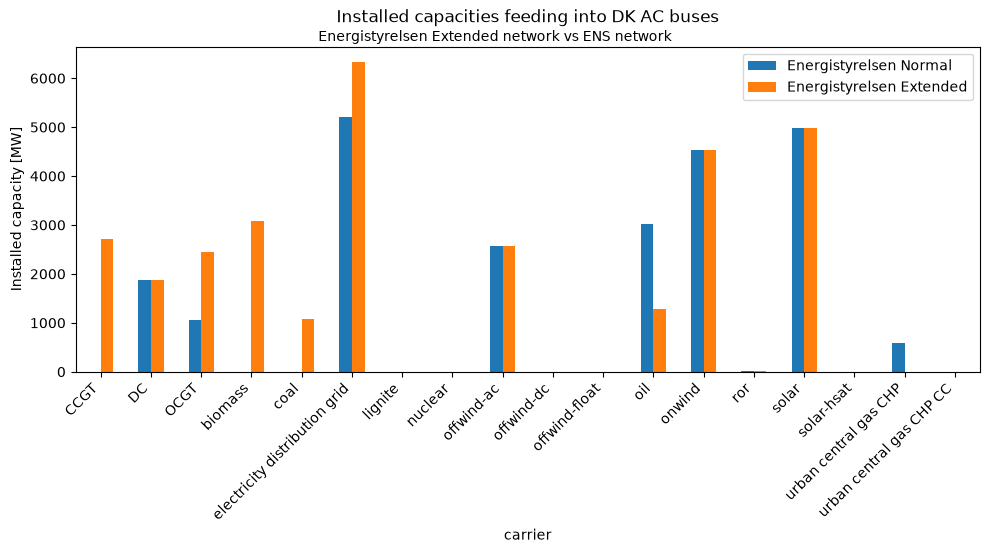

In [ ]:
ac_comparison = pd.concat(
    [cap_ens_ac, cap_ext_ac], axis=1, keys=["Energistyrelsen Normal", "Energistyrelsen Extended"]
).fillna(0)

ac_comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title("Installed capacities feeding into DK AC buses", y=1.05)
plt.suptitle("Energistyrelsen Extended network vs ENS network", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
def dk_heat_capacity_by_carrier(network):
    dk_heat_buses = network.buses.index[
        network.buses["carrier"].str.contains("heat", case=False, na=False)
        & (network.buses["country"] == "DK")
    ]

    gens = network.generators.loc[
        network.generators["bus"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]
    storage = network.storage_units.loc[
        network.storage_units["bus"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]

    links = network.links.loc[
        network.links["bus0"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]

    

    components = pd.concat([gens, storage, links])
    
    return components.groupby("carrier")["p_nom_opt"].sum()


cap_ppm_heat = dk_heat_capacity_by_carrier(OG_network)

cap_ens_heat = dk_heat_capacity_by_carrier(ENS_network)

# Compare the heat capacities for Denmark between the original and Energistyrelsen networks
df_heat = pd.DataFrame({
    "Original Network": cap_ppm_heat,
    "Energistyrelsen Network": cap_ens_heat
})
df_heat


,Original Network,Energistyrelsen Network
carrier,,
rural air heat pump,0.195946,0.441101
rural ground heat pump,782.104234,799.473383
rural heat vent,0.042619,5.202815
rural solar thermal,0.069489,0.110353
rural water tanks charger,1.865843,3.168449
urban central air heat pump,738.262533,900.528102
urban central heat vent,0.018019,0.781587
urban central solar thermal,0.121012,0.182028
urban central water pits charger,1879.968744,2292.275820


In [ ]:
# sum from cap_ens_heat for only containing 'central'
sum_central_heat_ens = cap_ens_heat.loc[cap_ens_heat.index.str.contains(" central")].sum()
print(sum_central_heat_ens)

# sum for all
sum_all_heat_ens = df_heat['Energistyrelsen Network'].sum()
print(sum_all_heat_ens)

10953.93809861814
16927.849383091343


In [ ]:
df_heat

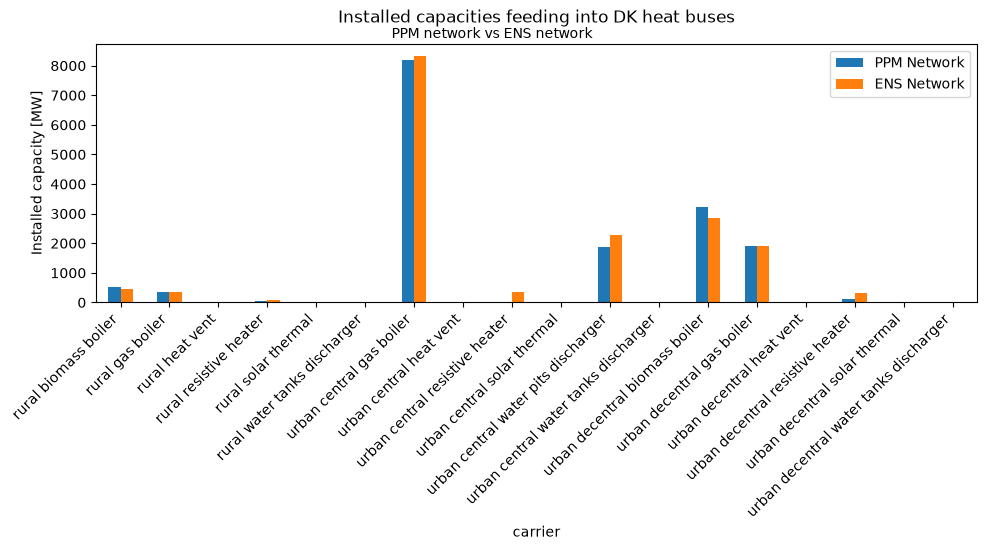

In [ ]:
heat_comparison = pd.concat(
    [cap_ppm_heat, cap_ens_heat], axis=1, keys=["PPM Network", "ENS Network"]
).fillna(0)

heat_comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title("Installed capacities feeding into DK heat buses", y=1.05)
plt.suptitle("PPM network vs ENS network", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Check total heat capacity of installed heat from df_ens_pp active in 2025


total_heat_capacity = df_ens_pp["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from Energistyrelsen data: {total_heat_capacity} MW')

# check how much of it is from combined heat and power (CHP) plants
chp_heat_capacity = df_ens_pp[df_ens_pp["elkapacitet_MW"] > 0]["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from CHP plants: {chp_heat_capacity} MW')

chp_power_capacity = df_ens_pp[(df_ens_pp["elkapacitet_MW"] > 0) & (df_ens_pp["varmekapacitet_MW"] > 0)]["elkapacitet_MW"].sum()
print(f'Total installed power capacity from CHP plants: {chp_power_capacity} MW')

# chp_power + chp_heat gives the total installed capacity of CHP plants
total_chp_capacity = chp_power_capacity + chp_heat_capacity
print(f'Total installed capacity from CHP plants: {total_chp_capacity} MW')

In [ ]:
# sum df heat energistyrelsen 
sum_network_ens = df_heat['Energistyrelsen Network'].sum()

In [ ]:
# check all anlaegtype_navn where varmekapacitet > 0
df_ens_pp[df_ens_pp["varmekapacitet_MW"] > 0]["anlaegstype_navn"].unique()

# sum for each anlaegstype_navn where varmekapacitet > 0
df_ens_pp[df_ens_pp["varmekapacitet_MW"] > 0].groupby("anlaegstype_navn")["varmekapacitet_MW"].sum()

In [ ]:
# Sum varmekapacitet_MW where fv_net_navn contains "fjernvarme"
mask = df_ens_pp["fv_net_navn"].str.contains(
    "fjernvarme",
    case=False,
    na=False,
)

sum_central_heat_pp = df_ens_pp.loc[
    mask, "varmekapacitet_MW"
].sum()

print(sum_central_heat_pp)

In [ ]:
heat_capacity_by_type = (
    df_ens_pp.loc[df_ens_pp["varmekapacitet_MW"] > 0]
    .groupby("anlaegstype_navn")["varmekapacitet_MW"]
    .sum()
    .sort_values(ascending=False)
)

ax = heat_capacity_by_type.plot(kind="bar", figsize=(12, 6))
ax.set_xlabel("Anlaegstype")
ax.set_ylabel("Total heat capacity [MW]")
ax.set_title("Total heat capacity by anlaegstype_navn")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# print all buses for Denmark in ENS network
ens_dk_buses = ENS_network.buses.index[ENS_network.buses["country"] == "DK"]
ENS_network.buses.loc[ens_dk_buses]